# Allocator Benchmarks on Unbounded Tasksets

Compare FFCap Adaptive Linear vs FFCap (u_target = 1.0) and
evaluate energy consumption under different DVFS/DPM policies
on unbounded and mixed-profile tasksets.

In [1]:
import os
import sys
import random
import multiprocessing as mp
from pathlib import Path
from functools import partial

sys.path.insert(0, str(Path("build/python").resolve()))

import pyschedsim as sim
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from scipy import stats
from IPython.display import clear_output

MAX_WORKERS = max(1, (os.cpu_count() or 1) - 1)
_mp_ctx = mp.get_context("fork")
print(f"Using {MAX_WORKERS} worker processes")

# Enable autoreload so local module changes propagate in notebooks.
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

Using 13 worker processes


In [2]:
PLATFORM = "platforms/exynos5422.json"
N_SCENARIOS = 100
SUCCESS_RATE = 0.5
COMPRESSION_RATE = 0.5
NUM_HYPERPERIODS = 100  # repeat job pattern over 100 hyperperiods for longer simulations
MIN_JOBS = 700  # minimum total jobs per scenario
UTIL_PER_TASK_MIN = 0.001
UTIL_PER_TASK_MAX = 0.133

# Exynos 5422 capacity: 4 big (perf=1.0) + 4 LITTLE (perf=0.3334)
BIG_CAP = 4 * 1.0
LITTLE_CAP = 4 * 0.3334
PLATFORM_CAP = BIG_CAP + LITTLE_CAP  # 5.3336

UTIL_MIN = 0.0
UTIL_MAX = 5.5
UTIL_STEP = 0.2

# Need enough tasks so that N_TASKS * UTIL_PER_TASK_MAX >= UTIL_MAX
N_TASKS = int(np.ceil(UTIL_MAX / UTIL_PER_TASK_MAX))  # 49
print(f"N_TASKS = {N_TASKS}  (per-task util in [{UTIL_PER_TASK_MIN}, {UTIL_PER_TASK_MAX}])")

util_points = np.round(np.arange(UTIL_MIN, UTIL_MAX + UTIL_STEP / 2, UTIL_STEP), 4)

N_TASKS = 42  (per-task util in [0.001, 0.133])


## Simulation helpers

In [3]:
def uunifast_discard(n, u_total, umin=0.0, umax=1.0, max_attempts=1_000_000):
    """UUniFast-Discard: generate n utilizations summing to u_total with each in [umin, umax]."""
    for _ in range(max_attempts):
        utils = []
        sum_u = u_total
        valid = True
        for i in range(n - 1):
            exp = 1.0 / (n - i - 1)
            next_sum = sum_u * random.random() ** exp
            u = sum_u - next_sum
            if u < umin or u > umax:
                valid = False
                break
            utils.append(u)
            sum_u = next_sum
        if valid and umin <= sum_u <= umax:
            utils.append(sum_u)
            return utils
    raise RuntimeError(
        f"uunifast_discard: no valid split after {max_attempts} attempts "
        f"(n={n}, u_total={u_total}, umin={umin}, umax={umax})")


def run_allocator_variant(taskset: dict, adaptive: bool) -> dict:
    """Run either FF Cap (u_target=1.0) or the adaptive linear allocator on one taskset."""
    engine = sim.Engine()
    sim.load_platform(engine, PLATFORM)
    scenario = sim.load_scenario(taskset["path"])

    tasks = sim.inject_scenario(engine, scenario)
    for i, task in enumerate(tasks):
        sim.schedule_arrivals(engine, task, scenario.tasks[i].jobs)
    engine.platform.finalize()

    platform = engine.platform
    ref_freq_max = max(
        platform.clock_domain(i).freq_max
        for i in range(platform.clock_domain_count)
    )

    clusters = []
    for i in range(platform.clock_domain_count):
        cd = platform.clock_domain(i)
        procs = cd.get_processors()
        if not procs:
            continue
        sched = sim.EdfScheduler(engine, procs)
        sched.enable_grub()
        sched.set_admission_test(sim.AdmissionTest.GFB)
        perf = procs[0].type().performance
        cluster = sim.Cluster(cd, sched, perf, ref_freq_max)
        if perf < 1.0:
            cluster.set_u_target(1.0)
        clusters.append(cluster)

    if adaptive:
        allocator = sim.FFCapAdaptiveLinearAllocator(engine, clusters)
        allocator.set_expected_total_util(taskset["total_util"])
        allocator_name = "ff_cap_adaptive_linear"
    else:
        allocator = sim.FFCapAllocator(engine, clusters)
        allocator_name = "ff_cap_u_target_1_0"

    writer = sim.MemoryTraceWriter()
    engine.set_trace_writer(writer)
    engine.run()

    metrics = writer.compute_metrics()
    total_arrivals = metrics.total_jobs + metrics.rejected_arrivals

    # Per-cluster utilization (sorted by perf ascending: LITTLE first, big last)
    sorted_clusters = sorted(clusters, key=lambda c: c.perf)
    little_util = sorted_clusters[0].utilization if len(sorted_clusters) > 0 else 0.0
    big_util = sorted_clusters[-1].utilization if len(sorted_clusters) > 1 else 0.0

    return {
        "total_util": taskset["total_util"],
        "seed": taskset["seed"],
        "allocator": allocator_name,
        "total_jobs": metrics.total_jobs,
        "completed_jobs": metrics.completed_jobs,
        "deadline_misses": metrics.deadline_misses,
        "rejected_arrivals": metrics.rejected_arrivals,
        "total_arrivals": total_arrivals,
        "little_util": little_util,
        "big_util": big_util,
    }

## Unbounded taskset generation

Generate tasksets with a fixed number of tasks (N_TASKS_UNBOUNDED)
using UUniFast-Discard with per-task utilization in
[UTIL_UNBOUNDED_LO, UTIL_UNBOUNDED_HI].

In [4]:
TASKSET_DIR_UNBOUNDED = "tasksets_unbounded"
N_SCENARIOS_UNBOUNDED = 1000
N_TASKS_UNBOUNDED = 15
UTIL_MIN_UNBOUNDED = 0.1
UTIL_STEP_UNBOUNDED = 0.1
UTIL_UNBOUNDED_LO = UTIL_PER_TASK_MIN
UTIL_UNBOUNDED_HI = 0.9
util_points_unbounded = np.round(
    np.arange(UTIL_MIN_UNBOUNDED, UTIL_MAX + UTIL_STEP_UNBOUNDED / 2, UTIL_STEP_UNBOUNDED), 4
)

def _generate_one_unbounded(util, scenario_idx):
    seed = int(round(util * 10000)) * 20000 + scenario_idx
    random.seed(seed)
    utils = uunifast_discard(N_TASKS_UNBOUNDED, util, UTIL_UNBOUNDED_LO, UTIL_UNBOUNDED_HI)
    folder = os.path.join(TASKSET_DIR_UNBOUNDED, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{scenario_idx + 1}.json")
    scenario = sim.from_utilizations(utils, SUCCESS_RATE, COMPRESSION_RATE, seed, NUM_HYPERPERIODS, 0)
    sim.write_scenario(scenario, path)
    return {
        "total_util": round(float(util), 4),
        "seed": seed,
        "utilizations": [float(u) for u in utils],
        "path": path,
    }


gen_args = [(util, idx) for util in util_points_unbounded for idx in range(N_SCENARIOS_UNBOUNDED)]
with _mp_ctx.Pool(MAX_WORKERS) as pool:
    tasksets_unbounded = pool.starmap(_generate_one_unbounded, gen_args)

print(f"Generated {len(tasksets_unbounded)} unbounded tasksets in {TASKSET_DIR_UNBOUNDED}/")

Generated 55000 unbounded tasksets in tasksets_unbounded/


### Unbounded utilization distribution

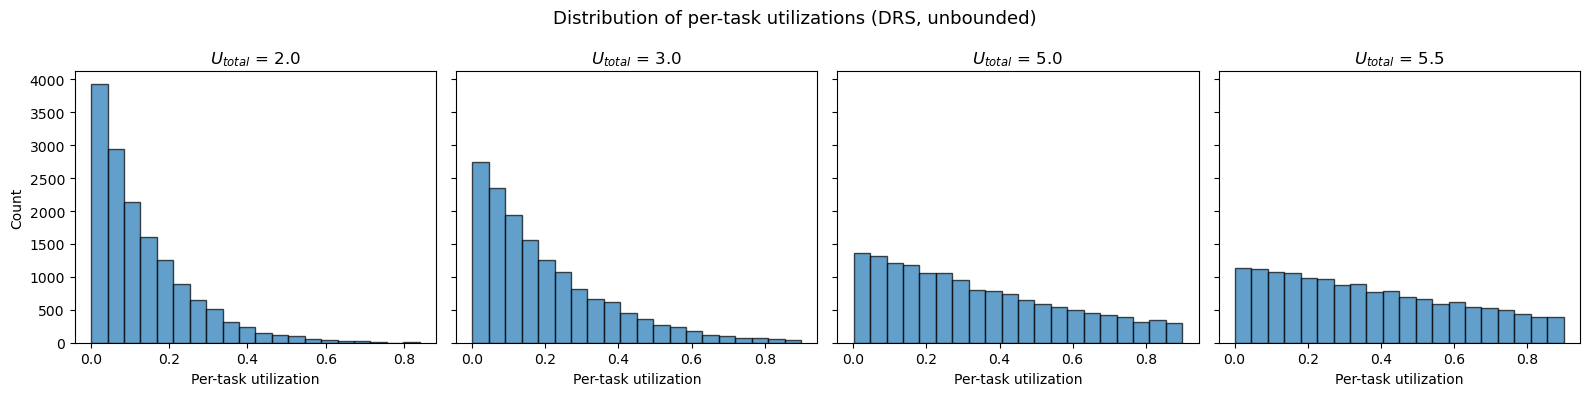

In [5]:
sample_points_unbounded = [2.0, 3.0, 5.0, round(UTIL_MAX, 1)]
fig, axes = plt.subplots(1, len(sample_points_unbounded), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points_unbounded):
    target_r = round(target, 4)
    all_utils = [u for t in tasksets_unbounded if t["total_util"] == target_r for u in t["utilizations"]]
    ax.hist(all_utils, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of per-task utilizations (DRS, unbounded)", fontsize=13)
plt.tight_layout()
plt.show()

### Job duration distribution

Show the distribution of actual job durations for one task in a sample
taskset, compared to the task's WCET, to illustrate the Weibull-based
execution time model.

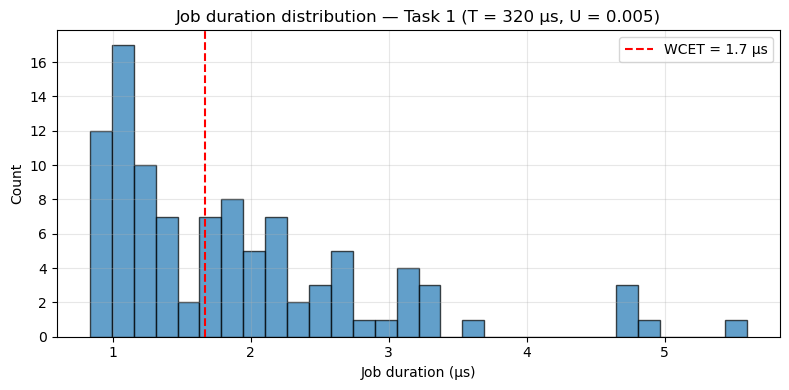

In [6]:
import json

sample_taskset = tasksets_unbounded[0]
with open(sample_taskset["path"]) as f:
    scenario_json = json.load(f)

task_data = scenario_json["tasks"][0]
durations = np.array([j["duration"] for j in task_data["jobs"]])
wcet = task_data["wcet"]
period = task_data["period"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(durations * 1e6, bins=30, edgecolor="black", alpha=0.7)
ax.axvline(wcet * 1e6, color="red", linestyle="--", linewidth=1.5, label=f"WCET = {wcet*1e6:.1f} µs")
ax.set_xlabel("Job duration (µs)")
ax.set_ylabel("Count")
ax.set_title(
    f"Job duration distribution — Task {task_data['id']} "
    f"(T = {period*1e6:.0f} µs, U = {sample_taskset['utilizations'][0]:.3f})"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Adaptive vs FFCap (u_target = 1.0) — unbounded tasksets

Compare the acceptance rate of the adaptive allocator against classic
FFCap with a permissive LITTLE-cluster threshold (`u_target = 1.0`)
on the unbounded tasksets.

In [7]:
comparison_args = [
    (taskset, is_adaptive)
    for _, is_adaptive in [("ff_cap_adaptive_linear", True), ("ff_cap_u_target_1_0", False)]
    for taskset in tasksets_unbounded
]

with _mp_ctx.Pool(MAX_WORKERS) as pool:
    comparison_rows = pool.starmap(run_allocator_variant, comparison_args)
print(f"Allocator comparison: {len(comparison_rows)} runs complete")

comparison_df = pl.DataFrame(comparison_rows)

Allocator comparison: 110000 runs complete


In [8]:
# Per-scenario acceptance rate: accepted / total_arrivals for each (seed, total_util)
comparison_per_scenario = (
    comparison_df.with_columns(
        (pl.col("total_arrivals") - pl.col("rejected_arrivals"))
        .truediv(pl.col("total_arrivals"))
        .alias("acceptance_rate")
    )
)

# Pivot so we have one row per scenario with both allocators side by side
adaptive_sc = (
    comparison_per_scenario
    .filter(pl.col("allocator") == "ff_cap_adaptive_linear")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_adaptive")])
)
baseline_sc = (
    comparison_per_scenario
    .filter(pl.col("allocator") == "ff_cap_u_target_1_0")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_baseline")])
)
paired = (
    adaptive_sc.join(baseline_sc, on=["total_util", "seed"])
    .with_columns((pl.col("acc_adaptive") - pl.col("acc_baseline")).alias("gain"))
    .sort(["total_util", "seed"])
)

### Statistical significance (Wilcoxon signed-rank test)

For each utilization point, test whether the adaptive allocator's
per-scenario acceptance rate differs significantly from FFCap.

In [9]:
def sig_label(p: float) -> str:
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


sig_rows = []
for util in sorted(paired["total_util"].unique().to_list()):
    gains = paired.filter(pl.col("total_util") == util)["gain"].to_numpy()
    mean_gain = float(gains.mean())
    if np.all(gains == 0):
        p_val = 1.0
    else:
        _, p_val = stats.wilcoxon(gains, alternative="two-sided")
    sig_rows.append({
        "total_util": util,
        "mean_gain_pct": round(mean_gain * 100, 4),
        "p_value": float(p_val),
        "significance": sig_label(p_val),
    })

sig_df = pl.DataFrame(sig_rows)
sig_df

total_util,mean_gain_pct,p_value,significance
f64,f64,f64,str
0.1,0.0,1.0,"""ns"""
0.2,0.0,1.0,"""ns"""
0.3,0.0,1.0,"""ns"""
0.4,0.0,1.0,"""ns"""
0.5,0.0,1.0,"""ns"""
…,…,…,…
5.1,7.1039,1.7656e-95,"""***"""
5.2,7.2064,2.8646e-95,"""***"""
5.3,6.1429,9.7116e-89,"""***"""


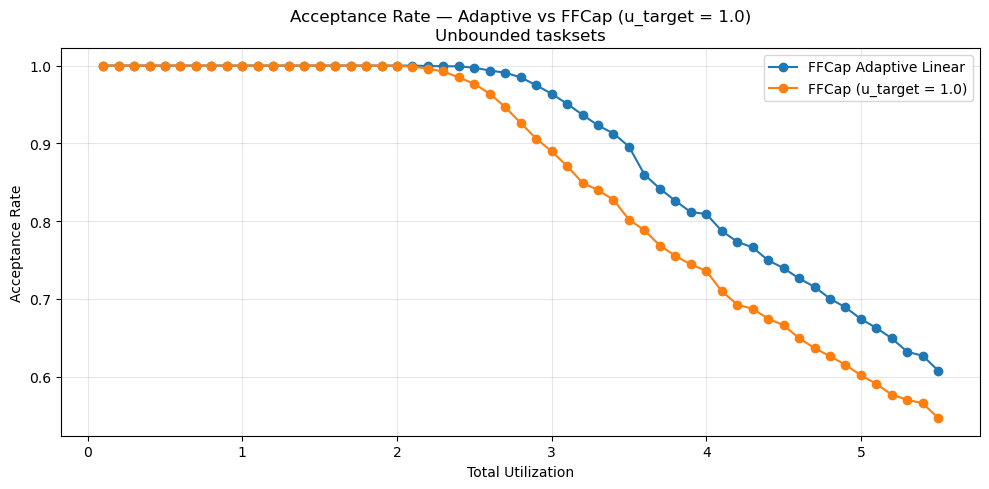

In [10]:
label_map = {
    "ff_cap_adaptive_linear": "FFCap Adaptive Linear",
    "ff_cap_u_target_1_0": "FFCap (u_target = 1.0)",
}

comparison_summary = (
    comparison_df.group_by(["allocator", "total_util"])
    .agg(
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["allocator", "total_util"])
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, label in label_map.items():
    data = comparison_summary.filter(pl.col("allocator") == name).sort("total_util")
    ax.plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, label=label,
    )

ax.set_xlabel("Total Utilization")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Acceptance Rate — Adaptive vs FFCap (u_target = 1.0)\nUnbounded tasksets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Deadline misses per allocator

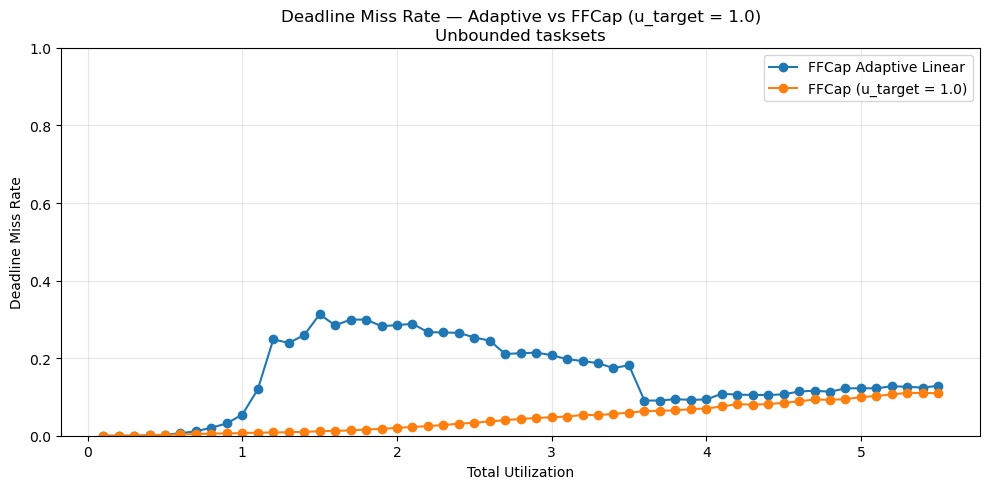

In [11]:
deadline_summary = (
    comparison_df.group_by(["allocator", "total_util"])
    .agg(
        deadline_miss_rate=pl.col("deadline_misses").sum() / pl.col("total_jobs").sum(),
    )
    .sort(["allocator", "total_util"])
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, label in label_map.items():
    data = deadline_summary.filter(pl.col("allocator") == name).sort("total_util")
    ax.plot(
        data["total_util"], data["deadline_miss_rate"],
        marker="o", linewidth=1.5, label=label,
    )

ax.set_xlabel("Total Utilization")
ax.set_ylabel("Deadline Miss Rate")
ax.set_ylim(0, 1)
ax.set_title("Deadline Miss Rate — Adaptive vs FFCap (u_target = 1.0)\nUnbounded tasksets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Per-cluster utilization

Average utilization admitted to the LITTLE and big clusters for each
allocator, showing how task placement differs.

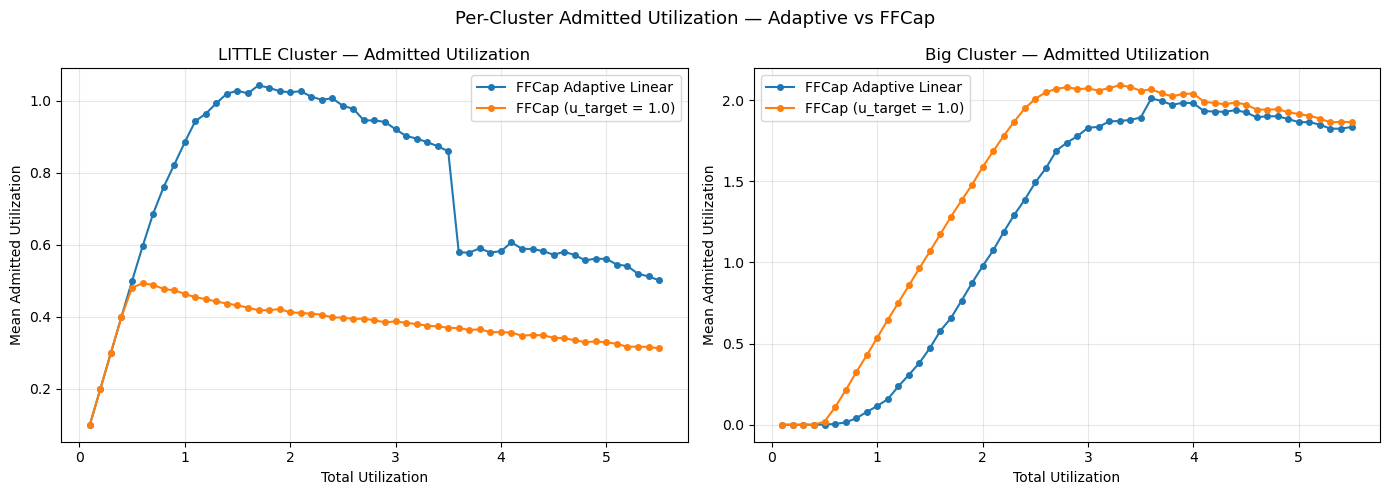

In [12]:
cluster_summary = (
    comparison_df.group_by(["allocator", "total_util"])
    .agg(
        mean_little_util=pl.col("little_util").mean(),
        mean_big_util=pl.col("big_util").mean(),
    )
    .sort(["allocator", "total_util"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, label in label_map.items():
    data = cluster_summary.filter(pl.col("allocator") == name).sort("total_util")
    axes[0].plot(
        data["total_util"], data["mean_little_util"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[0].set_xlabel("Total Utilization")
axes[0].set_ylabel("Mean Admitted Utilization")
axes[0].set_title("LITTLE Cluster — Admitted Utilization")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, label in label_map.items():
    data = cluster_summary.filter(pl.col("allocator") == name).sort("total_util")
    axes[1].plot(
        data["total_util"], data["mean_big_util"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[1].set_xlabel("Total Utilization")
axes[1].set_ylabel("Mean Admitted Utilization")
axes[1].set_title("Big Cluster — Admitted Utilization")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("Per-Cluster Admitted Utilization — Adaptive vs FFCap", fontsize=13)
plt.tight_layout()
plt.show()

### Acceptance rate gain (Adaptive − FFCap)

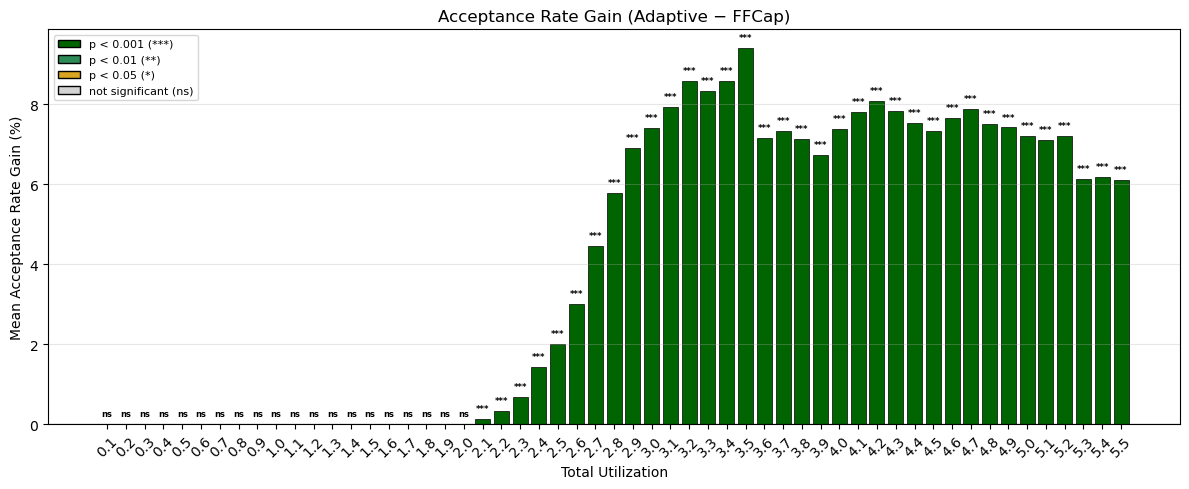

In [13]:
utils_arr = sig_df["total_util"].to_numpy()
gains_arr = sig_df["mean_gain_pct"].to_numpy()
sig_labels = sig_df["significance"].to_list()

SIG_COLORS = {"***": "darkgreen", "**": "seagreen", "*": "goldenrod", "ns": "lightgray"}

fig, ax = plt.subplots(figsize=(12, 5))
colors = [SIG_COLORS[s] for s in sig_labels]
bars = ax.bar(
    [f"{u:.1f}" for u in utils_arr], gains_arr,
    color=colors, edgecolor="black", linewidth=0.5,
)

for bar, label in zip(bars, sig_labels):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.15 if y >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width() / 2, y + offset, label,
            ha="center", va=va, fontsize=6, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Total Utilization")
ax.set_ylabel("Mean Acceptance Rate Gain (%)")
ax.set_title("Acceptance Rate Gain (Adaptive − FFCap)")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="darkgreen", edgecolor="black", label="p < 0.001 (***)"),
    Patch(facecolor="seagreen", edgecolor="black", label="p < 0.01 (**)"),
    Patch(facecolor="goldenrod", edgecolor="black", label="p < 0.05 (*)"),
    Patch(facecolor="lightgray", edgecolor="black", label="not significant (ns)"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Energy consumption — CSF vs FFA

Compare energy consumption of the CSF (Core Scaling First) and FFA
(Feedback-based Frequency Adaptation) DVFS/DPM policies on the
unbounded tasksets, using FFCap allocation with `u_target = 1.0`.

In [14]:
def run_energy_variant(taskset: dict, dvfs_policy: str) -> dict:
    """Run FFCap with a DVFS/DPM policy and return energy metrics."""
    engine = sim.Engine()
    sim.load_platform(engine, PLATFORM)
    engine.enable_energy_tracking(True)
    scenario = sim.load_scenario(taskset["path"])

    tasks = sim.inject_scenario(engine, scenario)
    for i, task in enumerate(tasks):
        sim.schedule_arrivals(engine, task, scenario.tasks[i].jobs)
    engine.platform.finalize()

    platform = engine.platform
    ref_freq_max = max(
        platform.clock_domain(i).freq_max
        for i in range(platform.clock_domain_count)
    )

    clusters = []
    for i in range(platform.clock_domain_count):
        cd = platform.clock_domain(i)
        procs = cd.get_processors()
        if not procs:
            continue
        sched = sim.EdfScheduler(engine, procs)
        sched.enable_grub()
        sched.set_admission_test(sim.AdmissionTest.GFB)
        if dvfs_policy == "csf":
            sched.enable_csf(cooldown=0.0)
        elif dvfs_policy == "ffa":
            sched.enable_ffa(cooldown=0.0)
        elif dvfs_policy == "grub_pa":
            sched.enable_power_aware_dvfs(cooldown=0.0)
        elif dvfs_policy == "grub":
            pass  # baseline: no DVFS, no DPM
        perf = procs[0].type().performance
        cluster = sim.Cluster(cd, sched, perf, ref_freq_max)
        if perf < 1.0:
            cluster.set_u_target(1.0)
        clusters.append(cluster)

    allocator = sim.FFCapAdaptiveLinearAllocator(engine, clusters)
    allocator.set_expected_total_util(taskset["total_util"])

    writer = sim.MemoryTraceWriter()
    engine.set_trace_writer(writer)
    engine.run()

    sim_duration_s = engine.time
    metrics = writer.compute_metrics()
    total_arrivals = metrics.total_jobs + metrics.rejected_arrivals
    avg_power_mw = metrics.total_energy_mj / sim_duration_s if sim_duration_s > 0 else 0.0

    return {
        "total_util": taskset["total_util"],
        "seed": taskset["seed"],
        "policy": dvfs_policy,
        "total_energy_mj": metrics.total_energy_mj,
        "sim_duration_s": sim_duration_s,
        "avg_power_mw": avg_power_mw,
        "total_jobs": metrics.total_jobs,
        "completed_jobs": metrics.completed_jobs,
        "deadline_misses": metrics.deadline_misses,
        "rejected_arrivals": metrics.rejected_arrivals,
        "total_arrivals": total_arrivals,
    }

In [15]:
ENERGY_POLICIES = [("grub", "GRUB"), ("grub_pa", "GRUB-PA"), ("csf", "CSF"), ("ffa", "FFA")]

energy_args = [
    (taskset, policy_key)
    for policy_key, _ in ENERGY_POLICIES
    for taskset in tasksets_unbounded
]

with _mp_ctx.Pool(MAX_WORKERS) as pool:
    energy_rows = pool.starmap(run_energy_variant, energy_args)
print(f"Energy benchmark: {len(energy_rows)} runs complete")

energy_df = pl.DataFrame(energy_rows)

Energy benchmark: 220000 runs complete


In [16]:
energy_summary = (
    energy_df.group_by(["policy", "total_util"])
    .agg(
        mean_avg_power_mw=pl.col("avg_power_mw").mean(),
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
        deadline_miss_rate=pl.col("deadline_misses").sum() / pl.col("total_jobs").sum(),
    )
    .sort(["policy", "total_util"])
)
energy_summary

policy,total_util,mean_avg_power_mw,acceptance_rate,deadline_miss_rate
str,f64,f64,f64,f64
"""csf""",0.1,2384.765126,1.0,0.000009
"""csf""",0.2,2412.44023,1.0,0.001075
"""csf""",0.3,2466.274259,1.0,0.004231
"""csf""",0.4,2535.456275,1.0,0.006872
"""csf""",0.5,2596.525107,1.0,0.009506
…,…,…,…,…
"""grub_pa""",5.1,3025.791203,0.662485,0.127385
"""grub_pa""",5.2,3024.387175,0.649038,0.133441
"""grub_pa""",5.3,3021.348827,0.631783,0.132113


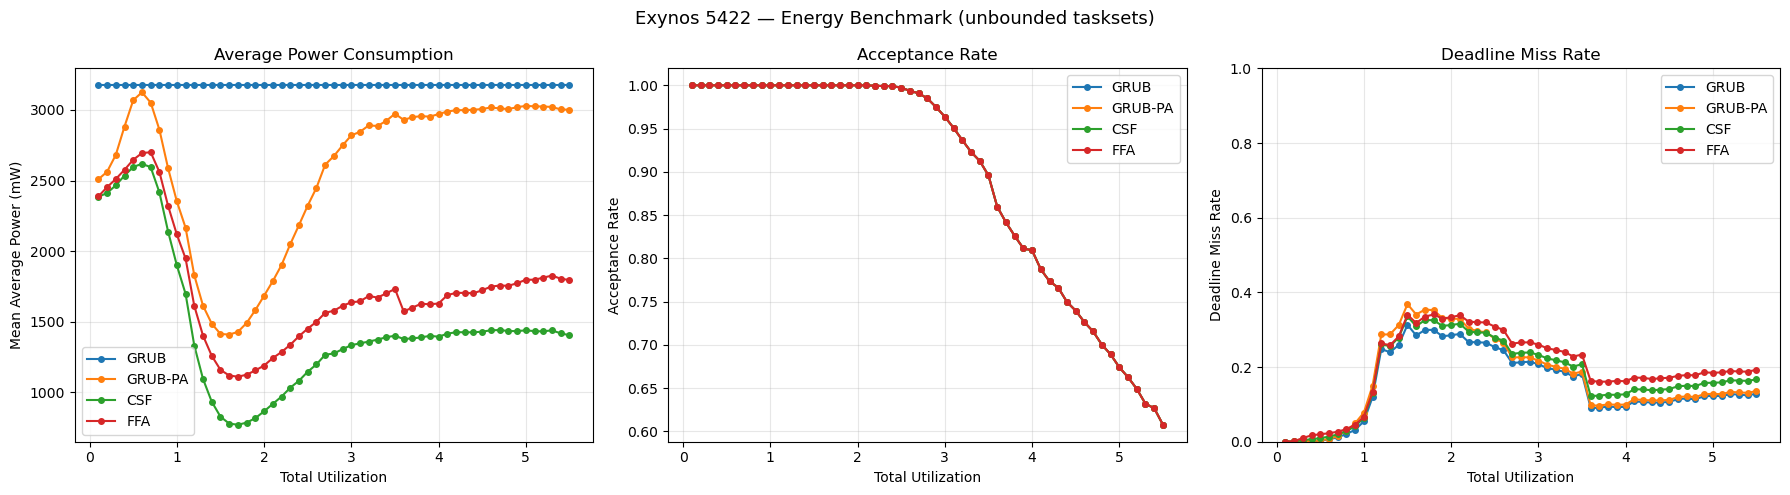

In [17]:
policy_labels = {"grub": "GRUB", "grub_pa": "GRUB-PA", "csf": "CSF", "ffa": "FFA"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average power consumption
for policy_key, label in policy_labels.items():
    data = energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[0].plot(
        data["total_util"], data["mean_avg_power_mw"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[0].set_xlabel("Total Utilization")
axes[0].set_ylabel("Mean Average Power (mW)")
axes[0].set_title("Average Power Consumption")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Acceptance rate
for policy_key, label in policy_labels.items():
    data = energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[1].plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[1].set_xlabel("Total Utilization")
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_title("Acceptance Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Deadline misses
for policy_key, label in policy_labels.items():
    data = energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[2].plot(
        data["total_util"], data["deadline_miss_rate"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[2].set_xlabel("Total Utilization")
axes[2].set_ylabel("Deadline Miss Rate")
axes[2].set_ylim(0, 1)
axes[2].set_title("Deadline Miss Rate")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Exynos 5422 — Energy Benchmark (unbounded tasksets)", fontsize=13)
plt.tight_layout()
plt.show()

## Mixed-profile taskset generation

Generate tasksets composed of three utilization classes to model a
heterogeneous workload:

| Share | Utilization range | Profile |
|-------|-------------------|---------|
| 40 %  | [0.01, 0.12]      | Light   |
| 20 %  | [0.25, 0.33]      | Medium  |
| 40 %  | [0.50, 0.80]      | Heavy   |

For each total utilization target, the budget is distributed across
classes proportionally to `n_class × midpoint`, then clamped to
feasible bounds and generated with DRS.

In [18]:
TASKSET_DIR_MIXED = "tasksets_mixed"
N_SCENARIOS_MIXED = 2000

# (fraction of tasks, lower bound, upper bound)
UTIL_CLASSES = [
    (0.40, 0.01, 0.10),  # light
    (0.20, 0.18, 0.22),  # medium
    (0.40, 0.50, 0.80),  # heavy
]

CLASS_MIDS = [(lo + hi) / 2 for _, lo, hi in UTIL_CLASSES]
FRAC_MID_SUM = sum(f * m for (f, _, _), m in zip(UTIL_CLASSES, CLASS_MIDS))


def compute_class_counts(total_util: float) -> list[int]:
    """Compute per-class task counts so the per-task average ≈ class midpoint.

    This gives DRS the best conditions for approximately uniform marginals.
    If the resulting counts can't accommodate total_util, the heavy class
    count is increased until feasible.
    """
    counts = [max(1, round(total_util * f / FRAC_MID_SUM)) for f, _, _ in UTIL_CLASSES]
    while sum(nc * hi for nc, (_, _, hi) in zip(counts, UTIL_CLASSES)) < total_util:
        counts[-1] += 1
    return counts


for util in [UTIL_MIN, (UTIL_MIN + UTIL_MAX) / 2, UTIL_MAX]:
    cc = compute_class_counts(util)
    print(f"U={util:.1f} → {sum(cc)} tasks: {cc}")
    for (frac, lo, hi), nc in zip(UTIL_CLASSES, cc):
        print(f"    {nc} tasks in [{lo}, {hi}] ({frac*100:.0f}%)")

U=0.0 → 3 tasks: [1, 1, 1]
    1 tasks in [0.01, 0.1] (40%)
    1 tasks in [0.18, 0.22] (20%)
    1 tasks in [0.5, 0.8] (40%)
U=2.8 → 8 tasks: [3, 2, 3]
    3 tasks in [0.01, 0.1] (40%)
    2 tasks in [0.18, 0.22] (20%)
    3 tasks in [0.5, 0.8] (40%)
U=5.5 → 17 tasks: [7, 3, 7]
    7 tasks in [0.01, 0.1] (40%)
    3 tasks in [0.18, 0.22] (20%)
    7 tasks in [0.5, 0.8] (40%)


In [19]:
def generate_mixed_utilizations(
    total_util: float,
    seed: int,
) -> list[float]:
    """Generate per-task utilizations for a mixed-profile taskset.

    The number of tasks per class is chosen so that the per-task average
    matches the class midpoint, giving DRS approximately uniform marginals.
    """
    random.seed(seed)
    cc = compute_class_counts(total_util)

    # Distribute total_util so per-task average ≈ class midpoint
    weights = [nc * mid for nc, mid in zip(cc, CLASS_MIDS)]
    total_weight = sum(weights)
    class_utils = [total_util * w / total_weight for w in weights]

    # Iteratively clamp and redistribute
    for _ in range(20):
        excess = 0.0
        unfixed = []
        for i, (nc, (_, lo, hi)) in enumerate(zip(cc, UTIL_CLASSES)):
            lo_sum, hi_sum = nc * lo, nc * hi
            if class_utils[i] < lo_sum:
                excess += class_utils[i] - lo_sum
                class_utils[i] = lo_sum
            elif class_utils[i] > hi_sum:
                excess += class_utils[i] - hi_sum
                class_utils[i] = hi_sum
            else:
                unfixed.append(i)
        if abs(excess) < 1e-10 or not unfixed:
            break
        for i in unfixed:
            class_utils[i] += excess / len(unfixed)

    # Clamp each class to its feasible range and call DRS
    all_utils = []
    for i, (nc, (_, lo, hi)) in enumerate(zip(cc, UTIL_CLASSES)):
        lo_sum, hi_sum = nc * lo, nc * hi
        class_utils[i] = max(lo_sum, min(hi_sum, class_utils[i]))
        if class_utils[i] <= lo_sum + 1e-10:
            utils = [lo] * nc
        elif class_utils[i] >= hi_sum - 1e-10:
            utils = [hi] * nc
        else:
            utils = uunifast_discard(nc, class_utils[i], lo, hi)
        all_utils.extend(utils)
    return all_utils


UTIL_MIN_MIXED = 1.0
UTIL_MAX_MIXED = 5.5
util_points_mixed = np.round(
    np.arange(UTIL_MIN_MIXED, UTIL_MAX_MIXED + UTIL_STEP / 2, UTIL_STEP), 4
)

def _generate_one_mixed(util, scenario_idx):
    seed = int(round(util * 10000)) * 30000 + scenario_idx
    utils = generate_mixed_utilizations(util, seed)
    folder = os.path.join(TASKSET_DIR_MIXED, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, f"{scenario_idx + 1}.json")
    scenario = sim.from_utilizations(utils, SUCCESS_RATE, COMPRESSION_RATE, seed, NUM_HYPERPERIODS, MIN_JOBS)
    sim.write_scenario(scenario, path)
    return {
        "total_util": round(float(util), 4),
        "seed": seed,
        "utilizations": [float(u) for u in utils],
        "path": path,
    }


mixed_gen_args = [(util, idx) for util in util_points_mixed for idx in range(N_SCENARIOS_MIXED)]
with _mp_ctx.Pool(MAX_WORKERS) as pool:
    tasksets_mixed = pool.starmap(_generate_one_mixed, mixed_gen_args)

print(f"Generated {len(tasksets_mixed)} mixed-profile tasksets in {TASKSET_DIR_MIXED}/")

Generated 46000 mixed-profile tasksets in tasksets_mixed/


### Mixed-profile utilization distribution

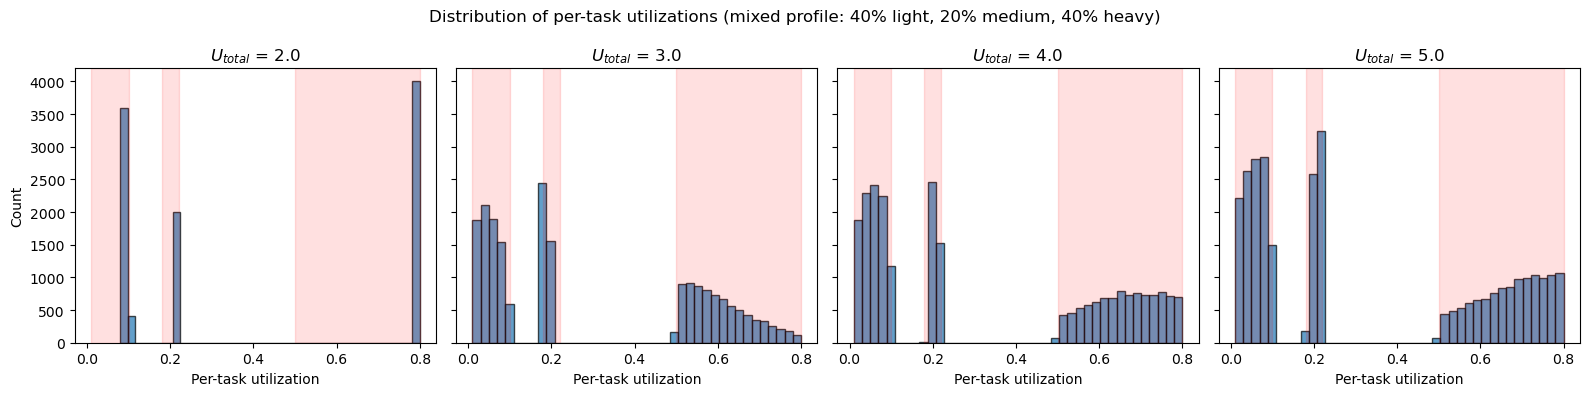

In [20]:
sample_points_mixed = [2.0, 3.0, 4.0, 5.0]
class_boundaries = [(lo, hi) for _, lo, hi in UTIL_CLASSES]

fig, axes = plt.subplots(1, len(sample_points_mixed), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points_mixed):
    target_r = round(target, 4)
    all_utils = [
        u for t in tasksets_mixed if t["total_util"] == target_r
        for u in t["utilizations"]
    ]
    ax.hist(all_utils, bins=40, edgecolor="black", alpha=0.7)
    for lo, hi in class_boundaries:
        ax.axvspan(lo, hi, alpha=0.12, color="red")
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle(
    "Distribution of per-task utilizations (mixed profile: "
    "40% light, 20% medium, 40% heavy)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Adaptive vs FFCap (u_target = 1.0) — mixed-profile tasksets

Same comparison as the unbounded section but on the mixed-profile
tasksets (40 % light / 20 % medium / 40 % heavy).

In [21]:
mixed_comparison_args = [
    (taskset, is_adaptive)
    for _, is_adaptive in [("ff_cap_adaptive_linear", True), ("ff_cap_u_target_1_0", False)]
    for taskset in tasksets_mixed
]

with _mp_ctx.Pool(MAX_WORKERS) as pool:
    mixed_comparison_rows = pool.starmap(run_allocator_variant, mixed_comparison_args)
print(f"Mixed comparison: {len(mixed_comparison_rows)} runs complete")

mixed_comparison_df = pl.DataFrame(mixed_comparison_rows)

Mixed comparison: 92000 runs complete


In [22]:
mixed_per_scenario = (
    mixed_comparison_df.with_columns(
        (pl.col("total_arrivals") - pl.col("rejected_arrivals"))
        .truediv(pl.col("total_arrivals"))
        .alias("acceptance_rate")
    )
)

mixed_adaptive_sc = (
    mixed_per_scenario
    .filter(pl.col("allocator") == "ff_cap_adaptive_linear")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_adaptive")])
)
mixed_baseline_sc = (
    mixed_per_scenario
    .filter(pl.col("allocator") == "ff_cap_u_target_1_0")
    .select(["total_util", "seed", pl.col("acceptance_rate").alias("acc_baseline")])
)
mixed_paired = (
    mixed_adaptive_sc.join(mixed_baseline_sc, on=["total_util", "seed"])
    .with_columns((pl.col("acc_adaptive") - pl.col("acc_baseline")).alias("gain"))
    .sort(["total_util", "seed"])
)

### Statistical significance (Wilcoxon signed-rank test)

In [23]:
def sig_label(p: float) -> str:
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


mixed_sig_rows = []
for util in sorted(mixed_paired["total_util"].unique().to_list()):
    gains = mixed_paired.filter(pl.col("total_util") == util)["gain"].to_numpy()
    mean_gain = float(gains.mean())
    if np.all(gains == 0):
        p_val = 1.0
    else:
        _, p_val = stats.wilcoxon(gains, alternative="two-sided")
    mixed_sig_rows.append({
        "total_util": util,
        "mean_gain_pct": round(mean_gain * 100, 4),
        "p_value": float(p_val),
        "significance": sig_label(p_val),
    })

mixed_sig_df = pl.DataFrame(mixed_sig_rows)
mixed_sig_df

total_util,mean_gain_pct,p_value,significance
f64,f64,f64,str
1.0,0.0,1.0,"""ns"""
1.2,0.0,1.0,"""ns"""
1.4,0.0,1.0,"""ns"""
1.6,0.0,1.0,"""ns"""
1.8,6.7642,1.8620e-110,"""***"""
…,…,…,…
4.6,-1.9419,2.0796e-64,"""***"""
4.8,-1.6244,1.0709e-48,"""***"""
5.0,-1.5116,7.2260e-39,"""***"""


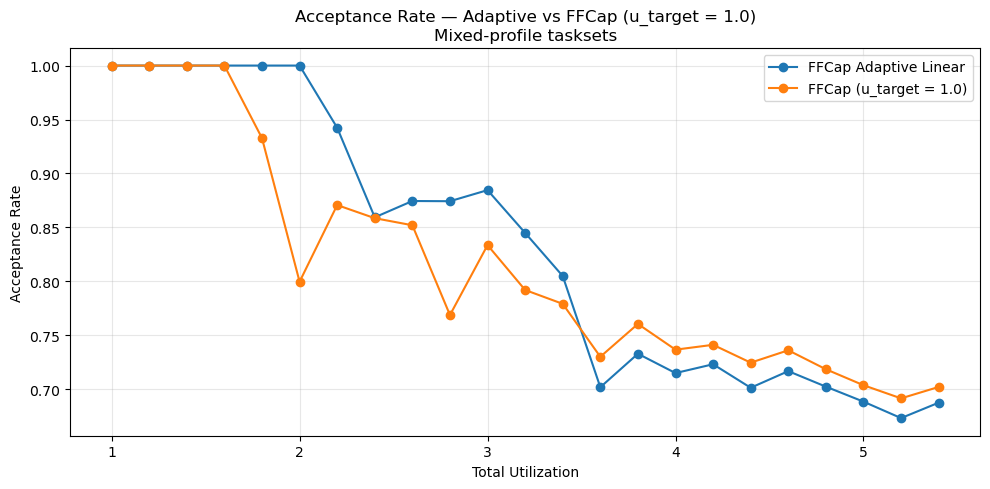

In [24]:
mixed_label_map = {
    "ff_cap_adaptive_linear": "FFCap Adaptive Linear",
    "ff_cap_u_target_1_0": "FFCap (u_target = 1.0)",
}

mixed_comparison_summary = (
    mixed_comparison_df.group_by(["allocator", "total_util"])
    .agg(
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["allocator", "total_util"])
)

fig, ax = plt.subplots(figsize=(10, 5))
for name, label in mixed_label_map.items():
    data = mixed_comparison_summary.filter(pl.col("allocator") == name).sort("total_util")
    ax.plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, label=label,
    )

ax.set_xlabel("Total Utilization")
ax.set_ylabel("Acceptance Rate")
ax.set_title("Acceptance Rate — Adaptive vs FFCap (u_target = 1.0)\nMixed-profile tasksets")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Acceptance rate gain (Adaptive − FFCap) — mixed profile

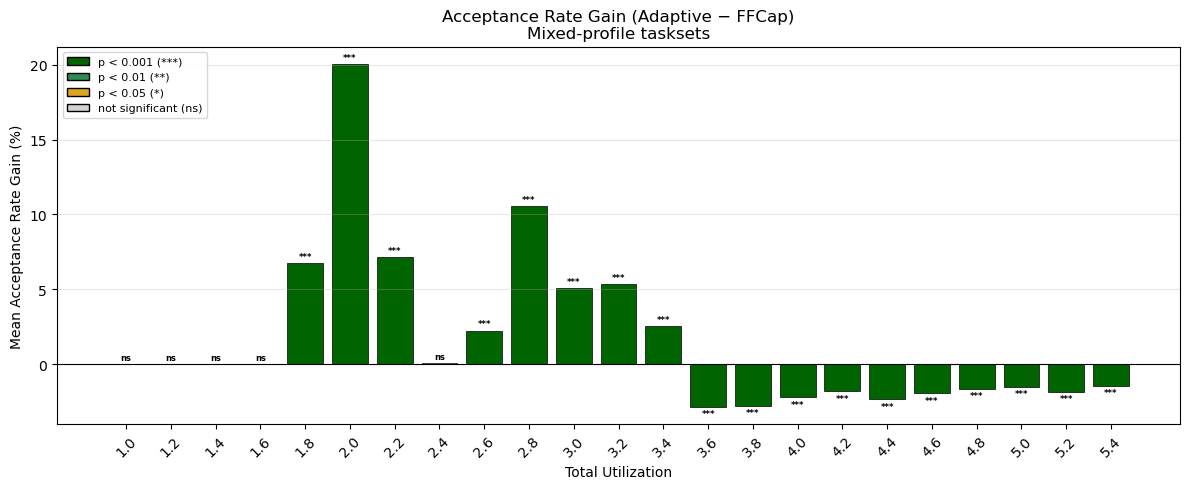

In [25]:
mixed_utils_arr = mixed_sig_df["total_util"].to_numpy()
mixed_gains_arr = mixed_sig_df["mean_gain_pct"].to_numpy()
mixed_sig_labels = mixed_sig_df["significance"].to_list()

SIG_COLORS_MIXED = {"***": "darkgreen", "**": "seagreen", "*": "goldenrod", "ns": "lightgray"}

fig, ax = plt.subplots(figsize=(12, 5))
colors_mixed = [SIG_COLORS_MIXED[s] for s in mixed_sig_labels]
bars = ax.bar(
    [f"{u:.1f}" for u in mixed_utils_arr], mixed_gains_arr,
    color=colors_mixed, edgecolor="black", linewidth=0.5,
)

for bar, label in zip(bars, mixed_sig_labels):
    y = bar.get_height()
    va = "bottom" if y >= 0 else "top"
    offset = 0.15 if y >= 0 else -0.15
    ax.text(bar.get_x() + bar.get_width() / 2, y + offset, label,
            ha="center", va=va, fontsize=6, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Total Utilization")
ax.set_ylabel("Mean Acceptance Rate Gain (%)")
ax.set_title("Acceptance Rate Gain (Adaptive − FFCap)\nMixed-profile tasksets")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, axis="y", alpha=0.3)

from matplotlib.patches import Patch
legend_elements_mixed = [
    Patch(facecolor="darkgreen", edgecolor="black", label="p < 0.001 (***)"),
    Patch(facecolor="seagreen", edgecolor="black", label="p < 0.01 (**)"),
    Patch(facecolor="goldenrod", edgecolor="black", label="p < 0.05 (*)"),
    Patch(facecolor="lightgray", edgecolor="black", label="not significant (ns)"),
]
ax.legend(handles=legend_elements_mixed, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

## Energy consumption — mixed-profile tasksets

Same DVFS/DPM comparison (GRUB, GRUB-PA, CSF, FFA) but on the
mixed-profile tasksets, which have a controlled number of tasks and
bounded per-task utilization at every utilization point.

In [26]:
mixed_energy_args = [
    (taskset, policy_key)
    for policy_key, _ in ENERGY_POLICIES
    for taskset in tasksets_mixed
]

with _mp_ctx.Pool(MAX_WORKERS) as pool:
    mixed_energy_rows = pool.starmap(run_energy_variant, mixed_energy_args)
print(f"Mixed energy benchmark: {len(mixed_energy_rows)} runs complete")

mixed_energy_df = pl.DataFrame(mixed_energy_rows)

Mixed energy benchmark: 184000 runs complete


In [27]:
mixed_energy_summary = (
    mixed_energy_df.group_by(["policy", "total_util"])
    .agg(
        mean_avg_power_mw=pl.col("avg_power_mw").mean(),
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
        deadline_miss_rate=pl.col("deadline_misses").sum() / pl.col("total_jobs").sum(),
    )
    .sort(["policy", "total_util"])
)
mixed_energy_summary

policy,total_util,mean_avg_power_mw,acceptance_rate,deadline_miss_rate
str,f64,f64,f64,f64
"""csf""",1.0,720.964409,1.0,0.482276
"""csf""",1.2,696.031654,1.0,0.280847
"""csf""",1.4,783.382379,1.0,0.275518
"""csf""",1.6,1012.316369,1.0,0.316883
"""csf""",1.8,1213.499041,1.0,0.379646
…,…,…,…,…
"""grub_pa""",4.6,2355.220847,0.716758,0.067642
"""grub_pa""",4.8,2362.267564,0.702379,0.071169
"""grub_pa""",5.0,2354.127996,0.688474,0.071005


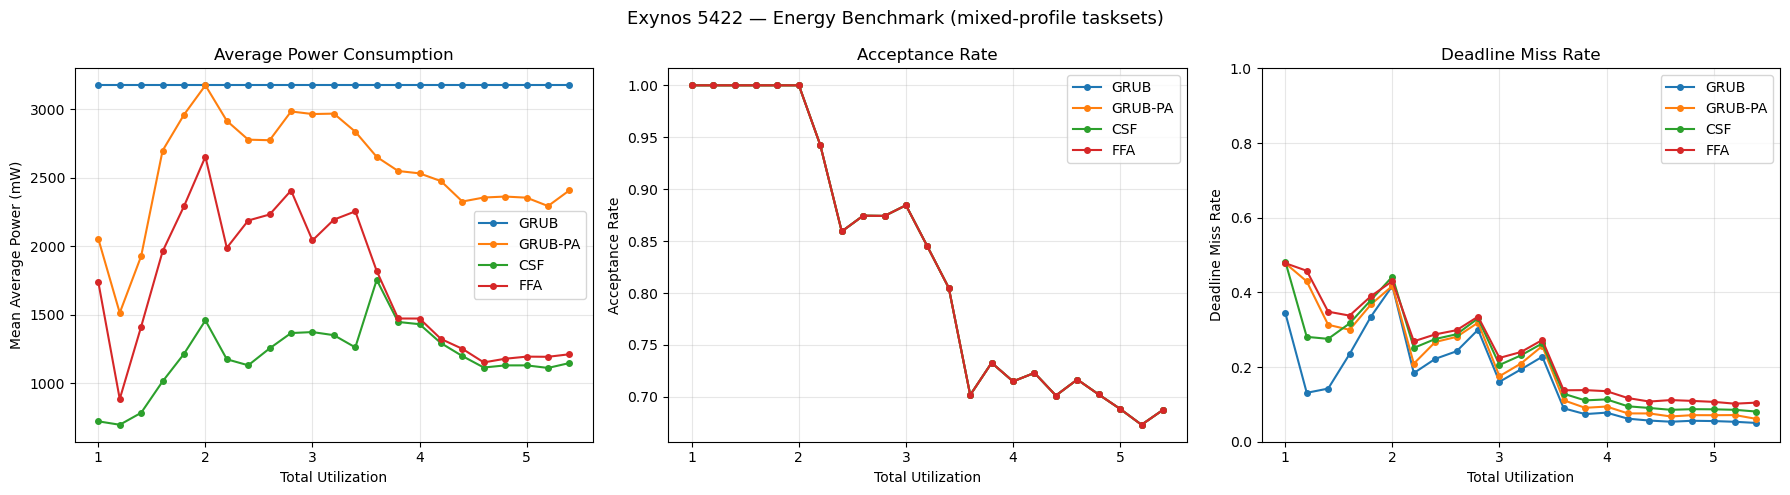

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for policy_key, label in policy_labels.items():
    data = mixed_energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[0].plot(
        data["total_util"], data["mean_avg_power_mw"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[0].set_xlabel("Total Utilization")
axes[0].set_ylabel("Mean Average Power (mW)")
axes[0].set_title("Average Power Consumption")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for policy_key, label in policy_labels.items():
    data = mixed_energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[1].plot(
        data["total_util"], data["acceptance_rate"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[1].set_xlabel("Total Utilization")
axes[1].set_ylabel("Acceptance Rate")
axes[1].set_title("Acceptance Rate")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for policy_key, label in policy_labels.items():
    data = mixed_energy_summary.filter(pl.col("policy") == policy_key).sort("total_util")
    axes[2].plot(
        data["total_util"], data["deadline_miss_rate"],
        marker="o", linewidth=1.5, markersize=4, label=label,
    )

axes[2].set_xlabel("Total Utilization")
axes[2].set_ylabel("Deadline Miss Rate")
axes[2].set_ylim(0, 1)
axes[2].set_title("Deadline Miss Rate")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Exynos 5422 — Energy Benchmark (mixed-profile tasksets)", fontsize=13)
plt.tight_layout()
plt.show()